Loaded data: (320, 85)


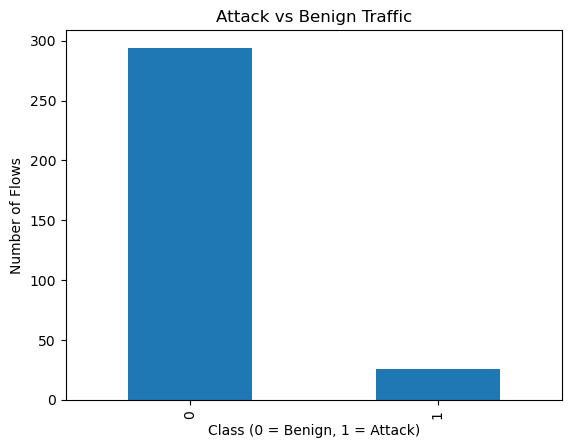

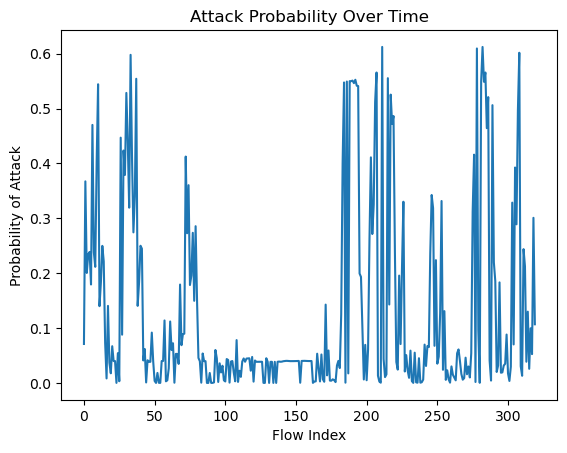

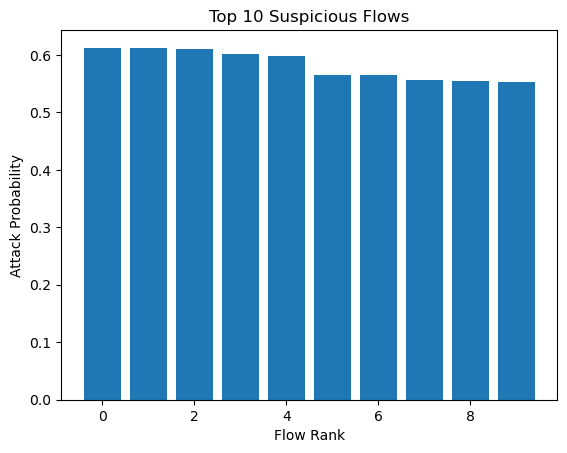


Graphs saved in: test_data/plots


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ── File paths ─────────────────────────────────────────────
DATA_FILE = "test_data/final_predictions.csv"
PLOT_DIR  = "test_data/plots"

# Create folder if it doesn't exist
os.makedirs(PLOT_DIR, exist_ok=True)

if not os.path.exists(DATA_FILE):
    print("ERROR: final_predictions.csv not found. Run detect.py first.")
    exit()

df = pd.read_csv(DATA_FILE)

print("Loaded data:", df.shape)

# ──────────────────────────────────────────────────────────
# GRAPH 1 — Attack vs Benign
# ──────────────────────────────────────────────────────────
counts = df["Ensemble_Pred"].value_counts()

plt.figure()
counts.plot(kind="bar")

plt.title("Attack vs Benign Traffic")
plt.xlabel("Class (0 = Benign, 1 = Attack)")
plt.ylabel("Number of Flows")

plt.savefig(os.path.join(PLOT_DIR, "attack_vs_benign.png"))
plt.show()


# ──────────────────────────────────────────────────────────
# GRAPH 2 — Attack Probability Over Time
# ──────────────────────────────────────────────────────────
plt.figure()

plt.plot(df["Ensemble_Prob"].values)

plt.title("Attack Probability Over Time")
plt.xlabel("Flow Index")
plt.ylabel("Probability of Attack")

plt.savefig(os.path.join(PLOT_DIR, "probability_over_time.png"))
plt.show()


# ──────────────────────────────────────────────────────────
# GRAPH 3 — Top Suspicious Flows
# ──────────────────────────────────────────────────────────
top = df.sort_values(by="Ensemble_Prob", ascending=False).head(10)

plt.figure()

plt.bar(range(len(top)), top["Ensemble_Prob"])

plt.title("Top 10 Suspicious Flows")
plt.xlabel("Flow Rank")
plt.ylabel("Attack Probability")

plt.savefig(os.path.join(PLOT_DIR, "top_suspicious_flows.png"))
plt.show()


print("\nGraphs saved in:", PLOT_DIR)